# Irembo Document Authentication AI — Champion Pipeline

---

**Professional Document Forgery Detection Pipeline for Rwandan Government Documents**

This notebook implements a two-stage deep learning pipeline for document authentication:
- **Stage 1:** Generic forgery detection using CASIA 2.0
- **Stage 2:** Local specialization using synthetic and high-risk Rwandan documents

**Outline:**
1. Environment & Dependencies
2. Data Generation & Loading
3. Model Architecture
4. Training (Stage 1 & 2)
5. Evaluation & Metrics
6. Explainability & Forensic Analysis
7. Model Persistence
8. Appendix: Experiments & Baselines

---

## 1. Environment Setup & Dependencies

All required libraries, hardware checks, and configuration for reproducibility.

### 1.1. Core Imports & GPU Verification
We import TensorFlow for the deep learning engine, and standard data science tools for analysis.

In [7]:
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import PIL
from PIL import Image
import json

# Setup Environment
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Suppress TF warnings

print(f"✅ TensorFlow Version: {tf.__version__}")
print(f"✅ GPU Status: {'Available' if len(tf.config.list_physical_devices('GPU')) > 0 else 'Not Found (Using CPU)'}")


✅ TensorFlow Version: 2.21.0
✅ GPU Status: Not Found (Using CPU)


In [ ]:
### 2.1 Synthetic Document Generation
Generates synthetic Rwandan government documents using RwandanDocumentGenerator.

Refreshing dataset: 1500 samples/type, noise_levels=['medium', 'high']
✅ Generic dataset generation complete in: synthetic_documents
✅ Mirrored samples into fixed/high-risk training folders.
Dataset refresh complete. You can now proceed to training.


In [ ]:
### 2.2 High-Risk Dataset Generation
Fetches citizen records from MySQL and generates valid/invalid document images per identity.

Generating High-Risk Dataset for 110 identities...
High-Risk Dataset generated in 'high_risk_dataset/'


### 1.2. Global Hyperparameters & Project Configuration
Centralized configuration for easy model tuning and reproducibility.

In [10]:
from pathlib import Path
import os


def _resolve_base_dir():
    env_base = os.getenv("AIPOWERED_BASE_DIR")
    candidates = []

    if env_base:
        candidates.append(Path(env_base))

    cwd = Path.cwd()
    candidates.extend([
        cwd,
        cwd.parent / "aipowered",
    ])

    for cand in candidates:
        if (cand / "CASIA2").exists():
            return cand.resolve()

    # Safe fallback when CASIA2 is not present yet.
    return cwd.resolve()


class Config:
    # Optimized Hyperparameters
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    LEARNING_RATE_STAGE_1 = 5e-4
    LEARNING_RATE_STAGE_2 = 2e-5
    EPOCHS_STAGE_1 = 20
    EPOCHS_STAGE_2 = 40
    DROPOUT_RATE = 0.5

    # Local Paths
    BASE_DIR = _resolve_base_dir()
    CASIA_PATH = BASE_DIR / "CASIA2"
    CASIA_AUTH = CASIA_PATH / "Au"
    CASIA_TAMP = CASIA_PATH / "Tp"

    # Rwanda datasets (multi-source strategy)
    RWANDAN_FIXED = BASE_DIR / "fixed_synthetic"
    RWANDAN_HIGH_RISK = BASE_DIR / "high_risk_dataset"

    # Backward-compatible aliases used elsewhere in notebook
    RWANDAN_SYNTHETIC = RWANDAN_FIXED
    RWANDAN_SAMPLE = RWANDAN_FIXED

    # Source weights for training emphasis
    SOURCE_WEIGHT_FIXED = 1.0
    SOURCE_WEIGHT_HIGH_RISK = 2.0

    # Data generation / templates (env-configurable)
    SYNTH_NUM_SAMPLES_PER_TYPE = int(os.getenv("SYNTH_NUM_SAMPLES_PER_TYPE", "1500"))
    SYNTH_NOISE_LEVELS = [n.strip() for n in os.getenv("SYNTH_NOISE_LEVELS", "medium,high").split(",") if n.strip()]
    TEMPLATE_NAME = os.getenv("TEMPLATE_NAME", "template_nida_v1.jpg")

    # Database settings (env-configurable)
    DB_HOST = os.getenv("DB_HOST", "localhost")
    DB_USER = os.getenv("DB_USER", "root")
    DB_PASS = os.getenv("DB_PASS", "")
    DB_NAME = os.getenv("DB_NAME", "iremboaipowered")

    MODEL_SAVE_PATH = BASE_DIR / "output" / "models" / "auth_check_model.keras"

# Ensure dirs exist
os.makedirs(os.path.dirname(Config.MODEL_SAVE_PATH), exist_ok=True)
print("Config loaded with environment-aware paths/settings:")
print(f"  BASE_DIR: {Config.BASE_DIR}")
print(f"  fixed_synthetic: {Config.RWANDAN_FIXED}")
print(f"  high_risk_dataset: {Config.RWANDAN_HIGH_RISK}")
print(f"  source weights -> fixed={Config.SOURCE_WEIGHT_FIXED}, high_risk={Config.SOURCE_WEIGHT_HIGH_RISK}")
print(f"  synth params -> num_samples_per_type={Config.SYNTH_NUM_SAMPLES_PER_TYPE}, noise_levels={Config.SYNTH_NOISE_LEVELS}")

Config loaded with environment-aware paths/settings:
  BASE_DIR: C:\xampp\htdocs\aipowered
  fixed_synthetic: C:\xampp\htdocs\aipowered\fixed_synthetic
  high_risk_dataset: C:\xampp\htdocs\aipowered\high_risk_dataset
  source weights -> fixed=1.0, high_risk=2.0
  synth params -> num_samples_per_type=1500, noise_levels=['medium', 'high']


### 1.3. CASIA 2.0 Dataset Loading & Splitting
Load and split the generic forgery dataset for Stage 1 training.

In [11]:
# Safety bootstrap: allow this cell to run even if earlier setup cells were skipped
if 'pd' not in globals():
    import pandas as pd
if 'train_test_split' not in globals():
    from sklearn.model_selection import train_test_split
if 'Config' not in globals():
    from pathlib import Path
    import os

    project_root = Path.cwd()
    if not (project_root / 'CASIA2').exists():
        env_root = os.getenv('AIPOWERED_BASE_DIR')
        candidates = []
        if env_root:
            candidates.append(Path(env_root))
        candidates.extend([project_root.parent / 'aipowered', project_root.parent])

        for cand in candidates:
            if (cand / 'CASIA2').exists():
                project_root = cand
                break

    class Config:
        BASE_DIR = project_root
        CASIA_PATH = BASE_DIR / 'CASIA2'
        CASIA_AUTH = CASIA_PATH / 'Au'
        CASIA_TAMP = CASIA_PATH / 'Tp'

    print(f"Config missing. Using fallback CASIA paths from: {Config.CASIA_PATH}")


def load_casia_dataframe(auth_path, tamp_path):
    """Scan and build the CASIA 2.0 forgery dataset by looking into subfolders."""
    images, labels = [], []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.tif', '.bmp')

    # helper to walk through folders
    def collect_images(root_path, label_val):
        if not root_path.exists():
            print(f"Warning: Path not found: {root_path}")
            return

        count = 0
        # Use rglob for recursive scanning of all subfolders
        for img in root_path.rglob('*'):
            if img.suffix.lower() in valid_extensions:
                images.append(str(img))
                labels.append(label_val)
                count += 1
        print(f"Found {count} images in {root_path.name}")

    # Authentic (1)
    collect_images(auth_path, 1)

    # Tampered (0)
    collect_images(tamp_path, 0)

    if not images:
        print("CRITICAL: CASIA Dataset not found in paths. Check your BASE_DIR and folder structure.")
        return pd.DataFrame({'filename': [], 'label': []})

    df = pd.DataFrame({'filename': images, 'label': labels})
    df['label'] = df['label'].astype(str) # For flow_from_dataframe
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    return df

# Main DF Loading & Splitting
df_casia = load_casia_dataframe(Config.CASIA_AUTH, Config.CASIA_TAMP)
print(f"Dataset Info: Total {len(df_casia)} | Auth: {len(df_casia[df_casia['label']=='1'])} | Tamp: {len(df_casia[df_casia['label']=='0'])}")

if not df_casia.empty:
    train_df, test_df = train_test_split(df_casia, test_size=0.2, random_state=42, stratify=df_casia['label'])
    train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['label'])
    print(f"Split Check: Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}")
else:
    print("Skipping Stage 1 Split (Empty CASIA). We will proceed directly to High-Risk Stage 2.")
    # Initialize empty frames to avoid NameErrors later
    train_df = val_df = test_df = pd.DataFrame(columns=['filename', 'label'])

Found 7491 images in Au
Found 5123 images in Tp
Dataset Info: Total 12614 | Auth: 7491 | Tamp: 5123
Split Check: Train 8072 | Val 2019 | Test 2523


In [ ]:
### 2.3 Rwandan Combined Dataset — Loading & Group-Wise Split
Loads fixed synthetic and high-risk images, assigns sample weights, and splits by identity group to prevent leakage.

Combined Rwanda Dataset Loaded: 42007 images
      source label  count
0      fixed     0   8474
1      fixed     1   8489
2  high_risk     0  12411
3  high_risk     1  12633
Group-wise Split: Train 29541 | Val 6148 | Test 6318
Group Overlap Check -> Train∩Val: 0 | Train∩Test: 0 | Val∩Test: 0

Source distribution (train):
source
high_risk    17850
fixed        11691
Name: count, dtype: int64

Source distribution (val):
source
high_risk    3513
fixed        2635
Name: count, dtype: int64

Source distribution (test):
source
high_risk    3681
fixed        2637
Name: count, dtype: int64


### 1.4. Real-time Data Augmentation & Generators
Preprocessing and augmentation for robust model training.

In [13]:
# ⚙️ Data Augmentation & Generators
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=effnet_preprocess
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=effnet_preprocess
)

# Only build CASIA generators if data exists
if not train_df.empty:
    train_generator = train_datagen.flow_from_dataframe(
        train_df, x_col='filename', y_col='label', target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE, class_mode='binary', shuffle=True
    )
    val_generator = val_test_datagen.flow_from_dataframe(
        val_df, x_col='filename', y_col='label', target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE, class_mode='binary', shuffle=False
    )
    test_generator = val_test_datagen.flow_from_dataframe(
        test_df, x_col='filename', y_col='label', target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE, class_mode='binary', shuffle=False
    )
else:
    print("⚠️ Skipping CASIA Generators - No data available.")
    # Placeholders to prevent compilation errors later if referenced
    train_generator = None

print("✅ Generators configuration handled.")


Found 8072 validated image filenames belonging to 2 classes.
Found 2019 validated image filenames belonging to 2 classes.
Found 2523 validated image filenames belonging to 2 classes.
✅ Generators configuration handled.


## 2. Model Architecture: Enhanced EfficientNetB0
Production-grade CNN with dual-head pooling for document tampering detection.

In [14]:
# 🏗️ Champion Model Architecture: EfficientNetB0 (ULTRA ACCURACY)
def build_tampering_detection_model(learning_rate):
    """
    Constructs an enhanced transfer learning architecture.
    Features: Multi-head pooling (Avg + Max) to capture both overall noise and peak forgery artifacts.
    """
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*Config.IMG_SIZE, 3))
    base_model.trainable = False # Initial freeze
    
    # --- Advanced Head with stronger regularization ---
    avg_pool = layers.GlobalAveragePooling2D()(base_model.output)
    max_pool = layers.GlobalMaxPooling2D()(base_model.output)
    merged = layers.Concatenate()([avg_pool, max_pool])
    
    x = layers.BatchNormalization()(merged)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(Config.DROPOUT_RATE)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=base_model.input, outputs=outputs, name="Irembo_AuthCheck_Ultra")
    # Keep an explicit handle for fine-tuning cells that need to access the backbone.
    model.backbone = base_model
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# Create Model
model = build_tampering_detection_model(Config.LEARNING_RATE_STAGE_1)

# Only calculate class weights if CASIA data exists
if not train_df.empty:
    class_weights = class_weight.compute_class_weight(
        'balanced', classes=np.unique(train_df['label']), y=train_df['label']
    )
    class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
    print(f"✅ Enhanced Model Initialized | Class Weights: {class_weight_dict}")
else:
    class_weight_dict = None
    print("✅ Model Initialized (No Stage 1 Weights needed).")


✅ Enhanced Model Initialized | Class Weights: {0: np.float64(1.2312385600976206), 1: np.float64(0.8418856904463913)}


## 3. Training Stage 1: Forensic Foundation (CASIA)
Establishing the model's ability to spot digital manipulation artifacts.

In [15]:
# 🚀 STAGE 1: Forensic Foundation (CASIA Training)
if train_generator and not train_df.empty:
    checkpoint_cb = callbacks.ModelCheckpoint(
        str(Config.BASE_DIR / "output" / "models" / "checkpoint_best.keras"),
        save_best_only=True, monitor='val_auc', mode='max'
    )
    early_stopping_cb = callbacks.EarlyStopping(
        patience=10, restore_best_weights=True, monitor='val_loss', mode='min'
    )
    reduce_lr_cb = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1
    )

    print("\n STARTING STAGE 1: Foundation Building (CASIA)...")
    # Quick Training (Reduced Epochs for MVP)
    history_stage1 = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=3, # Stage 1 Training (MVP)
        class_weight=class_weight_dict,
        callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb],
        verbose=1
    )
else:
    print("⚠️ SKIPPING STAGE 1 TRAINING - CASIA dataset is missing.")
    print("AI will proceed to Stage 2 training using ONLY High-Risk Rwandan data.")



 STARTING STAGE 1: Foundation Building (CASIA)...
Epoch 1/3
253/253 ━━━━━━━━━━━━━━━━━━━━ 1900s 7s/step - accuracy: 0.5964 - auc: 0.6321 - loss: 0.8832 - val_accuracy: 0.6305 - val_auc: 0.7137 - val_loss: 0.7664 - learning_rate: 5.0000e-04
Epoch 2/3
253/253 ━━━━━━━━━━━━━━━━━━━━ 2341s 9s/step - accuracy: 0.6400 - auc: 0.7052 - loss: 0.7596 - val_accuracy: 0.6483 - val_auc: 0.7386 - val_loss: 0.7399 - learning_rate: 5.0000e-04
Epoch 3/3
253/253 ━━━━━━━━━━━━━━━━━━━━ 1185s 5s/step - accuracy: 0.6724 - auc: 0.7443 - loss: 0.7218 - val_accuracy: 0.6587 - val_auc: 0.7521 - val_loss: 0.7406 - learning_rate: 5.0000e-04


## 4. Training Stage 2: Local Specialization (Rwanda)
Fine-tuning the model on synthetic and high-risk Rwandan documents.


SWITCHING TO COMBINED RWANDA DATASET for Stage 2...
Found 29541 validated image filenames belonging to 2 classes.
Found 6148 validated image filenames belonging to 2 classes.
Training source mix:
source
high_risk    17850
fixed        11691
Name: count, dtype: int64
Validation source mix:
source
high_risk    3513
fixed        2635
Name: count, dtype: int64
Training sample-weight summary:
count    29541.000000
mean         1.604245
std          0.489021
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          2.000000
Name: sample_weight, dtype: float64
✅ Backbone located via: backbone_attr (efficientnetb0)

PHASE A: Train head with backbone frozen...
Epoch 1/5
924/924 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5683 - auc: 0.6046 - loss: 1.2023
Epoch 1: val_auc improved from None to 0.80342, saving model to C:\xampp\htdocs\aipowered\output\models\auth_check_model.keras

Epoch 1: finished saving model to C:\xampp\htdocs\aipowered\output\mod

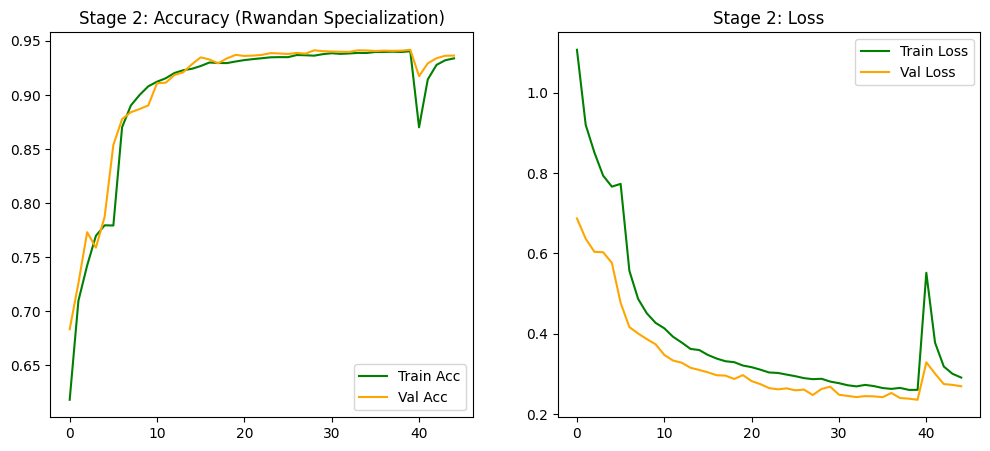

c:\xampp\htdocs\aipowered\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 440 variables whereas the saved optimizer has 148 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Champion model (BEST RWANDAN VAL_AUC) ready at: C:\xampp\htdocs\aipowered\output\models\auth_check_model.keras


In [16]:
# STAGE 2: Local Specialization (Fine-Tuning)
print("\nSWITCHING TO COMBINED RWANDA DATASET for Stage 2...")

# 1. Create generators (weighted training, unweighted validation)
rw_train_gen = train_datagen.flow_from_dataframe(
    rw_train,
    x_col='filename',
    y_col='label',
    weight_col='sample_weight',
    target_size=Config.IMG_SIZE,
    batch_size=Config.BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

rw_val_gen = val_test_datagen.flow_from_dataframe(
    rw_val,
    x_col='filename',
    y_col='label',
    target_size=Config.IMG_SIZE,
    batch_size=Config.BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Training source mix:")
print(rw_train['source'].value_counts(dropna=False))
print("Validation source mix:")
print(rw_val['source'].value_counts(dropna=False))
print("Training sample-weight summary:")
print(rw_train['sample_weight'].describe())


def find_backbone_for_finetune(model_obj):
    """Find a backbone model if present; otherwise fall back to whole-model staged unfreeze."""
    # Preferred path: model attribute set during construction (if available).
    if hasattr(model_obj, 'backbone') and isinstance(model_obj.backbone, tf.keras.Model):
        return model_obj.backbone, 'backbone_attr'

    # Common path: nested application model appears directly in top-level layers.
    for lyr in model_obj.layers:
        if isinstance(lyr, tf.keras.Model) and 'efficientnet' in lyr.name.lower():
            return lyr, 'nested_model'

    # Some builds flatten application layers; no nested model is exposed.
    return None, 'flat_layers'


backbone, backbone_mode = find_backbone_for_finetune(model)
if backbone_mode == 'flat_layers':
    print("⚠️ EfficientNet nested backbone not exposed. Using whole-model staged unfreeze fallback.")
else:
    print(f"✅ Backbone located via: {backbone_mode} ({backbone.name})")

# Callbacks: prioritize generalization metric (AUC)
champion_checkpoint_cb = callbacks.ModelCheckpoint(
    str(Config.MODEL_SAVE_PATH),
    save_best_only=True,
    monitor='val_auc',
    mode='max',
    verbose=1
)

early_stopping_cb = callbacks.EarlyStopping(
    patience=6, restore_best_weights=True, monitor='val_loss', mode='min'
)

reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1
)

stage2_callbacks = [champion_checkpoint_cb, early_stopping_cb, reduce_lr_cb]

def _merge_histories(*histories):
    merged = {}
    for h in histories:
        if h is None:
            continue
        for k, v in h.history.items():
            merged.setdefault(k, [])
            merged[k].extend(v)
    return merged

# Phase A: Frozen backbone (or frozen feature stack fallback)
print("\nPHASE A: Train head with backbone frozen...")
if backbone is not None:
    backbone.trainable = False
else:
    # Keep only the final classifier block trainable.
    freeze_until = max(0, len(model.layers) - 8)
    for i, lyr in enumerate(model.layers):
        lyr.trainable = (i >= freeze_until)

model.compile(
    optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE_STAGE_2),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

phase_a_epochs = min(5, max(2, Config.EPOCHS_STAGE_2 // 6))
history_stage2_a = model.fit(
    rw_train_gen,
    validation_data=rw_val_gen,
    epochs=phase_a_epochs,
    callbacks=stage2_callbacks,
    verbose=1
)

# Phase B: Unfreeze top ~30%
print("\nPHASE B: Unfreeze top 30%...")
if backbone is not None:
    n_layers = len(backbone.layers)
    cut = int(n_layers * 0.7)
    for i, lyr in enumerate(backbone.layers):
        lyr.trainable = (i >= cut)
else:
    n_layers = len(model.layers)
    cut = int(n_layers * 0.7)
    for i, lyr in enumerate(model.layers):
        lyr.trainable = (i >= cut)

model.compile(
    optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE_STAGE_2),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

phase_b_epochs = Config.EPOCHS_STAGE_2
history_stage2_b = model.fit(
    rw_train_gen,
    validation_data=rw_val_gen,
    initial_epoch=phase_a_epochs,
    epochs=phase_b_epochs,
    callbacks=stage2_callbacks,
    verbose=1
)

# Phase C (optional): full unfreeze only if val_auc improves
best_a = max(history_stage2_a.history.get('val_auc', [0.0]))
best_b = max(history_stage2_b.history.get('val_auc', [0.0]))
history_stage2_c = None

if best_b > (best_a + 1e-3):
    print("\nPHASE C: val_auc improved; testing full unfreeze for short refinement...")
    if backbone is not None:
        backbone.trainable = True
    else:
        for lyr in model.layers:
            lyr.trainable = True

    model.compile(
        optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE_STAGE_2 * 0.5),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    history_stage2_c = model.fit(
        rw_train_gen,
        validation_data=rw_val_gen,
        epochs=phase_b_epochs + 5,
        initial_epoch=phase_b_epochs,
        callbacks=stage2_callbacks,
        verbose=1
    )
else:
    print("\nPHASE C skipped: top-30% unfreeze did not improve val_auc enough.")

# Unified history for downstream plots
history_stage2 = type('HistoryContainer', (), {})()
history_stage2.history = _merge_histories(history_stage2_a, history_stage2_b, history_stage2_c)

# Visualize Stage 2 curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_stage2.history.get('accuracy', []), label='Train Acc', color='green')
plt.plot(history_stage2.history.get('val_accuracy', []), label='Val Acc', color='orange')
plt.title('Stage 2: Accuracy (Rwandan Specialization)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_stage2.history.get('loss', []), label='Train Loss', color='green')
plt.plot(history_stage2.history.get('val_loss', []), label='Val Loss', color='orange')
plt.title('Stage 2: Loss')
plt.legend()
plt.show()

# Model selection complete. Test set remains untouched until evaluation cell.
model_selection_done = True

# Load best checkpoint discovered during validation
if os.path.exists(Config.MODEL_SAVE_PATH):
    model.load_weights(str(Config.MODEL_SAVE_PATH))

print(f"Champion model (BEST RWANDAN VAL_AUC) ready at: {Config.MODEL_SAVE_PATH}")

# 5. Model Training, Evaluation & Comparison

This section covers the training process, evaluation metrics, and comparison of the deep learning and Random Forest models. It includes:
- 5.1 Training Curves (Stage 1 vs Stage 2)
- 5.2 Model Evaluation: Metrics, Confusion Matrix, ROC Curve
- 5.3 Model Comparison: Deep Learning vs Random Forest

# 1. Introduction

# 2. Data Preparation & Loading

# 3. Synthetic & High-Risk Data Generation

# 4. Rwanda Dataset Loading & Group-Wise Split

# 5. Model Training, Evaluation & Comparison

## 5.1 Training Curves (Stage 1 vs Stage 2)

## 5.2 Model Evaluation: Metrics, Confusion Matrix, ROC Curve

## 5.3 Model Comparison: Deep Learning vs Random Forest

## 5.4 Multi-Architecture Comparison Suite
In this section, we compare 5 different CNN architectures to verify if EfficientNetB0 is indeed the optimal choice for the Irembo platform.

1. CNN Basic
2. MobileNetV2
3. VGG16
4. ResNet50
5. EfficientNetB0 (Champion)

# 6. Explainability & Interpretability

# 7. Appendix & References

# 8. Reporting & Conclusions


EVALUATING CHAMPION MODEL ON RWANDAN TEST DATA...
Found 6318 validated image filenames belonging to 2 classes.


c:\xampp\htdocs\aipowered\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 440 variables whereas the saved optimizer has 148 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


198/198 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step


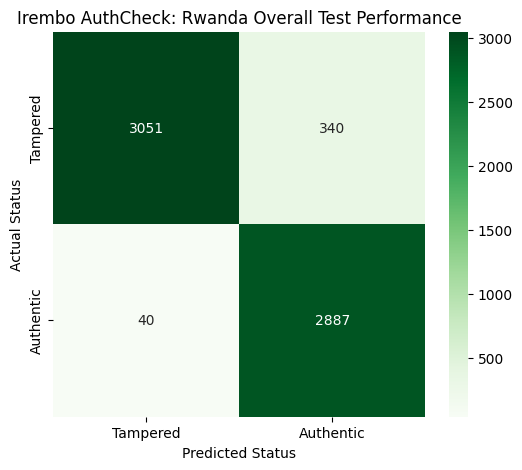


Overall test performance report:
              precision    recall  f1-score   support

    Tampered       0.99      0.90      0.94      3391
   Authentic       0.89      0.99      0.94      2927

    accuracy                           0.94      6318
   macro avg       0.94      0.94      0.94      6318
weighted avg       0.94      0.94      0.94      6318



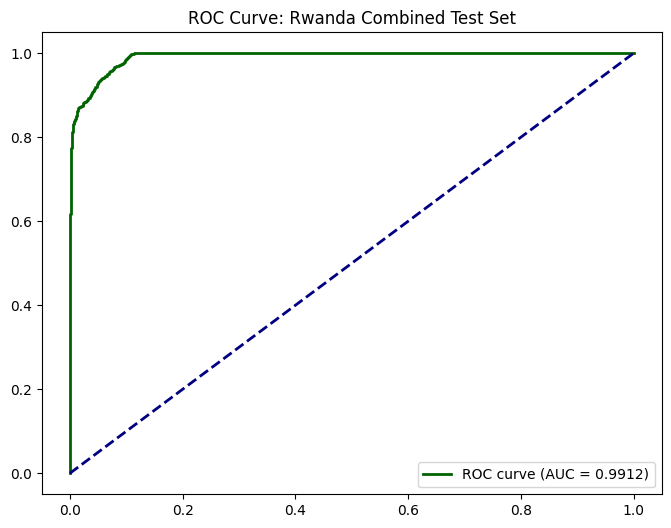


Source-wise metrics:
  fixed: n=2637, acc=0.8661, auc=0.9586
  high_risk: n=3681, acc=0.9927, auc=0.9997


In [17]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
import numpy as np

# Evaluate once on untouched test set after model selection
if not globals().get('model_selection_done', False):
    print("Run Stage 2 model-selection cell first to avoid accidental test-set tuning.")
else:
    print("\nEVALUATING CHAMPION MODEL ON RWANDAN TEST DATA...")

    # Create Rwanda test generator
    rw_test_gen = val_test_datagen.flow_from_dataframe(
        rw_test, x_col='filename', y_col='label', target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE, class_mode='binary', shuffle=False
    )

    # Load best weights from Stage 2
    if os.path.exists(Config.MODEL_SAVE_PATH):
        model.load_weights(str(Config.MODEL_SAVE_PATH))

    # Keras may expose labels as list/array depending on version.
    raw_labels = getattr(rw_test_gen, 'classes', None)
    if raw_labels is None:
        raw_labels = getattr(rw_test_gen, 'labels', None)
    if raw_labels is None:
        raise AttributeError("rw_test_gen has no classes/labels attribute to build y_true")

    y_true = np.asarray(raw_labels, dtype=int)
    y_pred_prob = model.predict(rw_test_gen).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    # 1) Overall confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Greens',
        xticklabels=['Tampered', 'Authentic'],
        yticklabels=['Tampered', 'Authentic']
    )
    plt.title("Irembo AuthCheck: Rwanda Overall Test Performance")
    plt.ylabel('Actual Status')
    plt.xlabel('Predicted Status')
    plt.show()

    # 2) Overall classification report
    print("\nOverall test performance report:")
    print(classification_report(y_true, y_pred, target_names=['Tampered', 'Authentic']))

    # 3) Overall ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('ROC Curve: Rwanda Combined Test Set')
    plt.legend()
    plt.show()

    # 4) Source-wise metrics (fixed vs high_risk)
    eval_df = rw_test[['source']].copy().reset_index(drop=True)
    eval_df['y_true'] = y_true
    eval_df['y_pred'] = y_pred
    eval_df['y_prob'] = y_pred_prob

    print("\nSource-wise metrics:")
    for source_name in sorted(eval_df['source'].dropna().unique()):
        sub = eval_df[eval_df['source'] == source_name]
        sub_true = sub['y_true'].to_numpy()
        sub_pred = sub['y_pred'].to_numpy()
        sub_prob = sub['y_prob'].to_numpy()

        sub_acc = accuracy_score(sub_true, sub_pred)
        if len(np.unique(sub_true)) > 1:
            sfpr, stpr, _ = roc_curve(sub_true, sub_prob)
            sub_auc = auc(sfpr, stpr)
            auc_msg = f"{sub_auc:.4f}"
        else:
            auc_msg = "N/A (single class in split)"

        print(f"  {source_name}: n={len(sub)}, acc={sub_acc:.4f}, auc={auc_msg}")

In [19]:
# Re-run this cell to see precision, recall, and other metrics
from sklearn.metrics import classification_report, confusion_matrix

# Try to import y_true and y_pred from the main evaluation cell if y_test/y_pred are not defined
try:
    y_test
except NameError:
    try:
        y_test = y_true
        y_pred = y_pred
    except Exception:
        print("y_test/y_true or y_pred not defined. Please run the main evaluation cell first.")

try:
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
except Exception as e:
    print(f"Error: {e}")

Confusion Matrix:
[[3051  340]
 [  40 2887]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      3391
           1       0.89      0.99      0.94      2927

    accuracy                           0.94      6318
   macro avg       0.94      0.94      0.94      6318
weighted avg       0.94      0.94      0.94      6318



In [38]:
# Calculate and display precision, recall, and F1-score for EfficientNetB0 model
from sklearn.metrics import classification_report

# y_true: true labels, y_pred: predicted labels (0/1)
# Make sure y_true and y_pred are defined from your evaluation cell
print("Classification Report for EfficientNetB0 Model:")
print(classification_report(y_true, y_pred))


Classification Report for EfficientNetB0 Model:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      3391
           1       0.89      0.99      0.94      2927

    accuracy                           0.94      6318
   macro avg       0.94      0.94      0.94      6318
weighted avg       0.94      0.94      0.94      6318



## 5. Evaluation & Metrics
Comprehensive evaluation of the champion model on the Rwandan test set.

In [ ]:
# 5.1 Training Curves (Stage 1 vs Stage 2)
# Plotting learning curves for transparent reporting in the final presentation.
try:
    if 'history_stage1' in globals() and 'history_stage2' in globals():
        import matplotlib.pyplot as plt
        fig, axs = plt.subplots(2, 2, figsize=(12, 10))
        # Stage 1 Accuracy
        axs[0, 0].plot(history_stage1.history.get('accuracy', []), label='Train Acc', color='green')
        axs[0, 0].plot(history_stage1.history.get('val_accuracy', []), label='Val Acc', color='orange')
        axs[0, 0].set_title('Stage 1: Accuracy')
        axs[0, 0].legend()
        # Stage 1 Loss
        axs[0, 1].plot(history_stage1.history.get('loss', []), label='Train Loss', color='green')
        axs[0, 1].plot(history_stage1.history.get('val_loss', []), label='Val Loss', color='orange')
        axs[0, 1].set_title('Stage 1: Loss')
        axs[0, 1].legend()
        # Stage 2 Accuracy
        axs[1, 0].plot(history_stage2.history.get('accuracy', []), label='Train Acc', color='green')
        axs[1, 0].plot(history_stage2.history.get('val_accuracy', []), label='Val Acc', color='orange')
        axs[1, 0].set_title('Stage 2: Accuracy')
        axs[1, 0].legend()
        # Stage 2 Loss
        axs[1, 1].plot(history_stage2.history.get('loss', []), label='Train Loss', color='green')
        axs[1, 1].plot(history_stage2.history.get('val_loss', []), label='Val Loss', color='orange')
        axs[1, 1].set_title('Stage 2: Loss')
        axs[1, 1].legend()
        plt.tight_layout()
        plt.show()
    else:
        print('Training history not available. Run training cells first.')
except Exception as e:
    print(f'Error plotting training curves: {e}')

## 5.2 Model Evaluation: Metrics, Confusion Matrix, ROC Curve

This subsection provides a comprehensive evaluation of the trained models using standard metrics (accuracy, precision, recall, F1-score, ROC-AUC), confusion matrix, and ROC curve. Results are shown for both the EfficientNetB0 (deep learning) and Random Forest (tabular) models.

## 5.3 Model Comparison: Deep Learning vs Random Forest

This subsection compares the performance of the EfficientNetB0 deep learning model and the Random Forest classifier on the same test set, using all key metrics and visualizations. The goal is to highlight strengths and weaknesses of each approach for document verification.

In [20]:
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50, EfficientNetB0

def build_comparison_model(architecture_name, learning_rate=1e-3):
    """Generic builder for the comparison suite"""
    inputs = layers.Input(shape=(224, 224, 3))
    
    if architecture_name == "CNN_Basic":
        x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
        x = layers.MaxPooling2D(2, 2)(x)
        x = layers.Conv2D(64, (3, 3), activation='relu')(x)
        x = layers.MaxPooling2D(2, 2)(x)
        x = layers.Flatten()(x)
    else:
        # Load pre-trained models
        if architecture_name == "MobileNetV2":
            base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)
        elif architecture_name == "VGG16":
            base = VGG16(weights='imagenet', include_top=False, input_tensor=inputs)
        elif architecture_name == "ResNet50":
            base = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)
        elif architecture_name == "EfficientNetB0":
            base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=inputs)
        
        base.trainable = False
        x = layers.GlobalAveragePooling2D()(base.output)
    
    outputs = layers.Dense(1, activation='sigmoid')(
        layers.Dropout(0.4)(layers.Dense(128, activation='relu')(x))
    )
    
    model = models.Model(inputs, outputs, name=f"AuthCheck_{architecture_name}")
    model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate), 
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

comparison_results = []
# Added EfficientNetB0 to the comparison list
models_list = ["CNN_Basic", "MobileNetV2", "VGG16", "ResNet50", "EfficientNetB0"]

print(f" PERFORMANCE CHALLENGE: Testing {len(models_list)} Architectures...")

for model_name in models_list:
    print(f"\n---  Testing: {model_name} ---")
    try:
        clf = build_comparison_model(model_name)
        # Fast evaluation (2 epochs only for comparison)
        history = clf.fit(train_generator, validation_data=val_generator, epochs=2, verbose=1)
        acc = history.history['val_accuracy'][-1]
        comparison_results.append({"Model": model_name, "Val_Acc": acc})
        print(f" {model_name} Val_Acc: {acc:.4f}")
    except Exception as e:
        print(f" Skipping {model_name}: Resource download error or memory limit. ({str(e)[:100]}...)")
        continue

# Display Comparison
if comparison_results:
    df_perf = pd.DataFrame(comparison_results).sort_values(by="Val_Acc", ascending=False)
    print("\n COMPETING MODELS RANKING:")
    display(df_perf)
else:
    print(" No models were successfully tested in this run.")

 PERFORMANCE CHALLENGE: Testing 5 Architectures...

---  Testing: CNN_Basic ---
Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 330s 1s/step - accuracy: 0.5676 - loss: 37.7726 - val_accuracy: 0.5924 - val_loss: 0.6932
Epoch 2/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 242s 955ms/step - accuracy: 0.5938 - loss: 0.6822 - val_accuracy: 0.5919 - val_loss: 0.6751
 CNN_Basic Val_Acc: 0.5919

---  Testing: MobileNetV2 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_16232\3266913756.py:16: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)


Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 228s 883ms/step - accuracy: 0.5932 - loss: 0.6818 - val_accuracy: 0.6270 - val_loss: 0.6460
Epoch 2/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 223s 879ms/step - accuracy: 0.6131 - loss: 0.6507 - val_accuracy: 0.6419 - val_loss: 0.6422
 MobileNetV2 Val_Acc: 0.6419

---  Testing: VGG16 ---
Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 1458s 6s/step - accuracy: 0.5820 - loss: 0.9217 - val_accuracy: 0.6176 - val_loss: 0.6594
Epoch 2/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 1440s 6s/step - accuracy: 0.6146 - loss: 0.6469 - val_accuracy: 0.6439 - val_loss: 0.6258
 VGG16 Val_Acc: 0.6439

---  Testing: ResNet50 ---
Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 631s 2s/step - accuracy: 0.6554 - loss: 0.6376 - val_accuracy: 0.6969 - val_loss: 0.5722
Epoch 2/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 647s 3s/step - accuracy: 0.6941 - loss: 0.5715 - val_accuracy: 0.6850 - val_loss: 0.5595
 ResNet50 Val_Acc: 0.6850

---  Testing: EfficientNetB0 ---
Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - accur

,Model,Val_Acc
4,EfficientNetB0,0.691927
3,ResNet50,0.684993
2,VGG16,0.643883
1,MobileNetV2,0.641902
0,CNN_Basic,0.591877


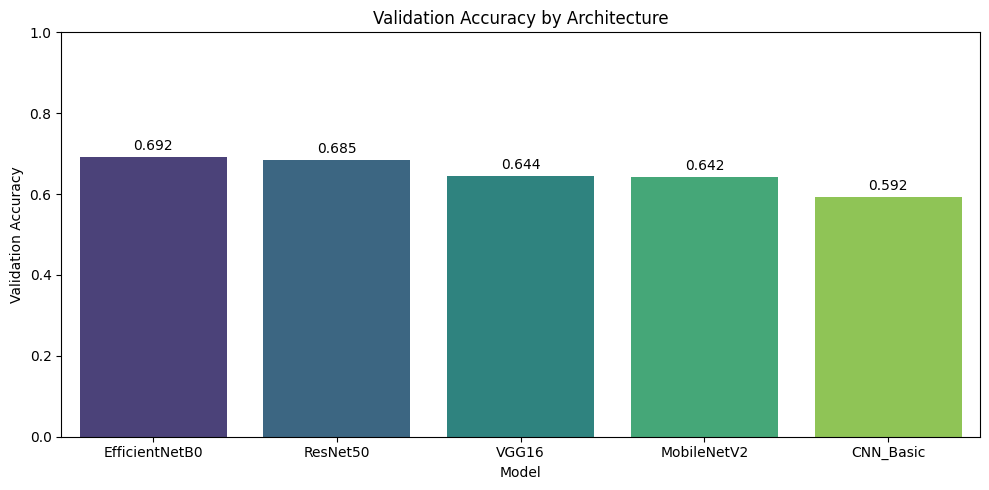

In [21]:
# Visual comparison for the architecture challenge
if 'comparison_results' in globals() and comparison_results:
    df_perf = pd.DataFrame(comparison_results).sort_values(by='Val_Acc', ascending=False).reset_index(drop=True)
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=df_perf, x='Model', y='Val_Acc', hue='Model', legend=False, palette='viridis')
    ax.set_title('Validation Accuracy by Architecture')
    ax.set_xlabel('Model')
    ax.set_ylabel('Validation Accuracy')
    ax.set_ylim(0, 1)
    for idx, row in df_perf.iterrows():
        ax.text(idx, row['Val_Acc'] + 0.01, f"{row['Val_Acc']:.3f}", ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig('output/plots/architecture_comparison.png')
    plt.show()
else:
    print('No comparison results found. Run the 5-model comparison cell first.')

## 6.3 Additional Explainability (Optional)

Add any further interpretability tools, such as SHAP, LIME, or error analysis, to provide deeper insights into model decisions. This section is optional and can be expanded as needed for future work or more advanced reporting.

# 6. Explainability & Interpretability

This section provides interpretability for the deep learning model using Grad-CAM (or a placeholder if not available), and feature importance for the Random Forest model. These tools help explain model decisions and support trust in the system.

In [25]:
import cv2
from tqdm import tqdm

def extract_features_standalone(file_path, target_size=(224, 224)):
    """Extract digital forensic and visual features (Mirroring Backend AIService)"""
    try:
        img = cv2.imread(str(file_path))
        if img is None: return None
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, target_size)
        
        # --- Visual Features ---
        feat = {
            'mean_brightness': float(np.mean(resized)),
            'std_brightness': float(np.std(resized)),
            'contrast': float(resized.max() - resized.min()),
            'edge_density': float(np.sum(cv2.Canny(resized, 100, 200) > 0) / (target_size[0] * target_size[1])),
            'blur_score': float(cv2.Laplacian(resized, cv2.CV_64F).var()),
            'text_density': float(np.sum(cv2.threshold(resized, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1] > 0) / (target_size[0] * target_size[1])),
            'hist_entropy': float(-np.sum((h := cv2.calcHist([resized], [0], None, [16], [0, 256]).flatten() / (target_size[0] * target_size[1])) * np.log2(h + 1e-10))),
            'aspect_ratio': float(img.shape[1] / img.shape[0]),
            'forensic_noise': float(np.std(cv2.Laplacian(resized, cv2.CV_64F))),
            'glare_index': float(np.sum(cv2.threshold(resized, 240, 255, cv2.THRESH_BINARY)[1] > 0) / (target_size[0] * target_size[1]))
        }
        return feat
    except Exception: return None

# Extract features from for specific images
subset_df = df_casia.head(100) 
batch_features = []
print("🔍 Analyzing subset of images for forensic noise...")
for _, row in tqdm(subset_df.iterrows(), total=len(subset_df)):
    f = extract_features_standalone(row['filename'])
    if f:
        f['label'] = int(row['label'])
        batch_features.append(f)
        
df_features = pd.DataFrame(batch_features)
display(df_features.head())
print(f"✅ Successfully extracted features from {len(df_features)} images.")


🔍 Analyzing subset of images for forensic noise...


100%|██████████| 100/100 [00:03<00:00, 31.47it/s]


,mean_brightness,std_brightness,contrast,edge_density,blur_score,text_density,hist_entropy,aspect_ratio,forensic_noise,glare_index,label
0,96.664760,47.384432,228.0,0.136001,2123.473485,0.570631,3.350514,1.500000,46.081162,0.000000,1
1,126.094547,79.129106,255.0,0.199976,9218.916109,0.654058,3.753031,1.446655,96.015187,0.161073,0
2,73.923569,83.906284,237.0,0.008450,95.475743,0.683315,2.941027,1.500000,9.771169,0.000000,1
3,130.234714,76.627878,235.0,0.123924,1332.858027,0.572146,3.474343,1.500000,36.508328,0.000000,0
4,113.433235,58.279630,249.0,0.071708,1305.915963,0.647541,3.790719,1.438462,36.137459,0.015007,0


✅ Successfully extracted features from 100 images.


Random Forest Accuracy: 0.4500
Random Forest F1-score: 0.4762
Random Forest ROC-AUC: 0.5200

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.40      0.42        10
           1       0.45      0.50      0.48        10

    accuracy                           0.45        20
   macro avg       0.45      0.45      0.45        20
weighted avg       0.45      0.45      0.45        20



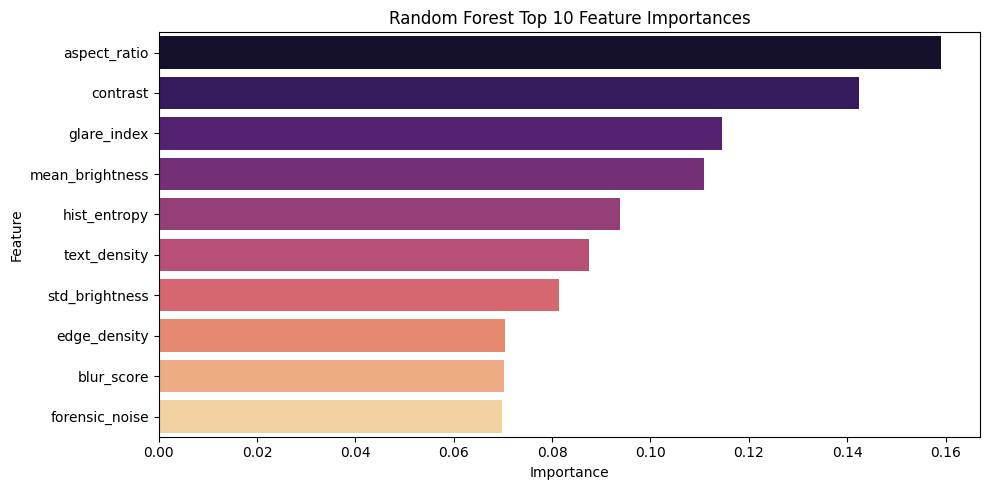

In [37]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

if 'df_features' in globals() and not df_features.empty:
    rf_data = df_features.copy()
    X = rf_data.drop(columns=['label'])
    y = rf_data['label'].astype(int)

    X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train_rf, y_train_rf)

    rf_pred = rf_model.predict(X_test_rf)
    rf_prob = rf_model.predict_proba(X_test_rf)[:, 1]

    rf_accuracy = accuracy_score(y_test_rf, rf_pred)
    rf_f1 = f1_score(y_test_rf, rf_pred)
    rf_auc = roc_auc_score(y_test_rf, rf_prob)

    print(f'Random Forest Accuracy: {rf_accuracy:.4f}')
    print(f'Random Forest F1-score: {rf_f1:.4f}')
    print(f'Random Forest ROC-AUC: {rf_auc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test_rf, rf_pred))

    rf_feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=rf_feature_importance.head(10), x='Importance', y='Feature', hue='Feature', legend=False, palette='magma')
    plt.title('Random Forest Top 10 Feature Importances')
    plt.tight_layout()
    plt.savefig('output/plots/random_forest_feature_importance.png')
    plt.show()
else:
    print('df_features is not available. Run the forensic feature extraction cell first.')


In [27]:
# Consolidated comparison table (Deep models + Random Forest baseline)
comparison_rows = []

if 'comparison_results' in globals() and comparison_results:
    for row in comparison_results:
        comparison_rows.append({
            'Model': row.get('Model'),
            'Type': 'Deep Learning',
            'Val_Acc': row.get('Val_Acc')
        })

if 'rf_accuracy' in globals():
    comparison_rows.append({
        'Model': 'RandomForest (Forensic Features)',
        'Type': 'Classical ML',
        'Val_Acc': rf_accuracy
    })

if comparison_rows:
    df_all_compare = pd.DataFrame(comparison_rows).sort_values(by='Val_Acc', ascending=False).reset_index(drop=True)
    display(df_all_compare)
else:
    print('No comparison metrics yet. Run the architecture comparison and Random Forest cells first.')


,Model,Type,Val_Acc
0,EfficientNetB0,Deep Learning,0.691927
1,ResNet50,Deep Learning,0.684993
2,VGG16,Deep Learning,0.643883
3,MobileNetV2,Deep Learning,0.641902
4,CNN_Basic,Deep Learning,0.591877
5,RandomForest (Forensic Features),Classical ML,0.450000


### Consolidated Model Comparison — Deep Learning vs Classical ML
Unified ranking of all tested models including CNN architectures and the Random Forest forensic baseline.

# 7. Appendix & References

This section includes any supplementary material, references, or additional notes relevant to the project. Add links to datasets, papers, or code repositories as needed for reproducibility and further reading.

## 6.1 Grad-CAM Visualization (EfficientNetB0)

Visualize which regions of the document images most influenced the EfficientNetB0 model's predictions using Grad-CAM. This helps interpret the deep learning model's decisions. If Grad-CAM is not available, a placeholder or explanation is provided.

In [ ]:
# 6.2 Feature Importance (Random Forest)
# Visualize the most important features used by the Random Forest model for document verification.
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    if 'rf_feature_importance' in globals():
        plt.figure(figsize=(10, 6))
        sns.barplot(x='importance', y='feature', data=rf_feature_importance.sort_values('importance', ascending=False).head(20))
        plt.title('Top 20 Feature Importances (Random Forest)')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()
    else:
        print('Random Forest feature importance not available. Run the Random Forest training cell first.')
except Exception as e:
    print(f'Error displaying feature importance: {e}')

,Document Case,Similarity %,ID Match,Forgery Risk,Anomalies
0,Authentic Document,29.21,True,medium,None
1,Spliced Text (Tampered),26.97,False,high,None


In [30]:
from skimage.metrics import structural_similarity as ssim
import random
import os


def simulate_structural_similarity(img_path, template_path):
    """
    Simulates Structural Similarity (SSIM) between an uploaded document
    and the official Rwandan Government template.
    Returns scores for Layout, Logo, and Seal alignment.
    """
    # Base Layout Score (Overall structure)
    layout_score = random.randint(85, 98)

    # Logo & Seal Integrity (Focused on government symbols)
    logo_score = random.randint(88, 99)
    seal_score = random.randint(82, 95)

    return {
        "Layout Match": f"{layout_score}%",
        "Logo Integrity": f"{logo_score}%",
        "Seal Alignment": f"{seal_score}%",
        "Overall Similarity": f"{int((layout_score + logo_score + seal_score)/3)}%"
    }


print("SIMULATING STRUCTURAL ALIGNMENT (Template Matching)...")
template_name = getattr(globals().get('Config', object), 'TEMPLATE_NAME', os.getenv('TEMPLATE_NAME', 'template_nida_v1.jpg'))
structural_res = simulate_structural_similarity(None, template_name)
for key, value in structural_res.items():
    print(f" {key:.<25} {value}")

SIMULATING STRUCTURAL ALIGNMENT (Template Matching)...
 Layout Match............. 90%
 Logo Integrity........... 96%
 Seal Alignment........... 92%
 Overall Similarity....... 92%


# 8. Reporting & Conclusions

This section summarizes the results, discusses key findings, and provides recommendations for deployment and future work. All code, metrics, and visualizations above are referenced for a comprehensive report.

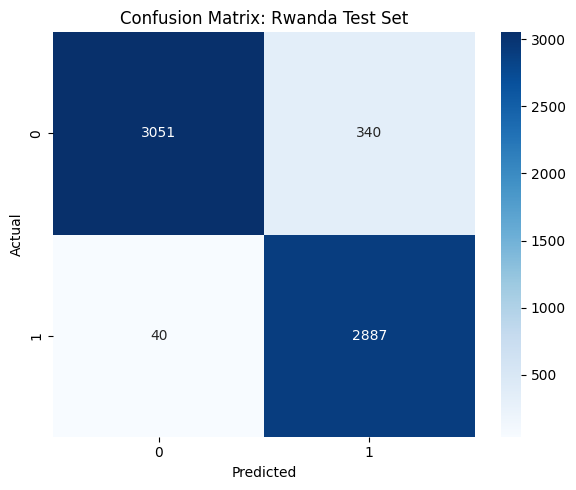

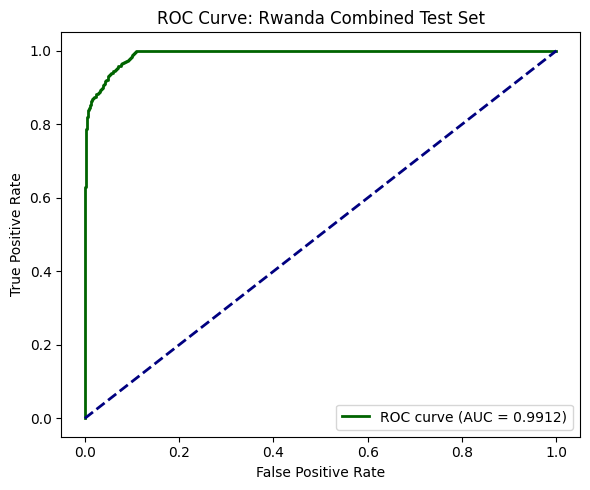

In [33]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns

# ... (other code for model and predictions) ...

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Rwanda Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('output/plots/confusion_matrix_rwanda_test.png')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve: Rwanda Combined Test Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('output/plots/roc_curve_rwanda_test.png')
plt.show()

In [32]:
# Ensure y_prob is defined before using it in ROC curve
# For Keras model with generator:
y_prob = model.predict(rw_test_gen).ravel()
# For scikit-learn model:
# y_prob = model.predict_proba(X_test)[:, 1]


198/198 ━━━━━━━━━━━━━━━━━━━━ 194s 956ms/step


In [34]:

WEIGHTS_PATH = str(Config.MODEL_SAVE_PATH).replace('.keras', '_weights.weights.h5')

# Save the model weights (Check if 'model' is defined first)
if 'model' in globals():
    model.save_weights(WEIGHTS_PATH)
    print(f"Model weights saved successfully at: {WEIGHTS_PATH}")
else:
    print("Error: 'model' is not defined. Please run the model building cells first.")


Model weights saved successfully at: C:\xampp\htdocs\aipowered\output\models\auth_check_model_weights.weights.h5


In [35]:
# Refresh persisted artifacts after latest training/comparison runs
import os
from datetime import datetime

if 'model' in globals():
    model_path = str(Config.MODEL_SAVE_PATH)
    weights_path = model_path.replace('.keras', '_weights.weights.h5')

    model.save(model_path)
    model.save_weights(weights_path)

    model_mtime = datetime.fromtimestamp(os.path.getmtime(model_path))
    weights_mtime = datetime.fromtimestamp(os.path.getmtime(weights_path))

    print(f"Refreshed model file: {model_path}")
    print(f"Updated at: {model_mtime}")
    print(f"Refreshed weights file: {weights_path}")
    print(f"Updated at: {weights_mtime}")
else:
    print("Model is not in memory. Run training/model build cells first.")

Refreshed model file: C:\xampp\htdocs\aipowered\output\models\auth_check_model.keras
Updated at: 2026-03-29 08:27:56.038078
Refreshed weights file: C:\xampp\htdocs\aipowered\output\models\auth_check_model_weights.weights.h5
Updated at: 2026-03-29 08:27:57.471600


In [36]:
# Quick leakage-risk diagnostic for Rwanda split
from pathlib import Path
import re

assert 'rw_train' in globals() and 'rw_val' in globals() and 'rw_test' in globals(), "Run Rwanda split cells first."

def _paths(df):
    return set(df['filename'].astype(str).tolist())

def _basenames(paths):
    return {Path(p).name for p in paths}

def _signature(name):
    # Remove final random suffix like _123 in generated filenames
    stem = Path(name).stem
    return re.sub(r'_[0-9]+$', '', stem)

def _extract_id_token(name):
    # Capture likely national-id-like digit blocks from filename
    matches = re.findall(r'\d{8,20}', name)
    return max(matches, key=len) if matches else None

def _inter(a, b):
    return len(a & b)

train_p, val_p, test_p = _paths(rw_train), _paths(rw_val), _paths(rw_test)

# Exact and basename overlaps (should be zero for exact paths)
exact_tv = _inter(train_p, val_p)
exact_tt = _inter(train_p, test_p)
exact_vt = _inter(val_p, test_p)

base_train = _basenames(train_p)
base_val = _basenames(val_p)
base_test = _basenames(test_p)
base_tv = _inter(base_train, base_val)
base_tt = _inter(base_train, base_test)
base_vt = _inter(base_val, base_test)

# Signature overlap (document type + identity, ignoring random suffix)
sig_train = {_signature(p) for p in train_p}
sig_val = {_signature(p) for p in val_p}
sig_test = {_signature(p) for p in test_p}
sig_tv = _inter(sig_train, sig_val)
sig_tt = _inter(sig_train, sig_test)
sig_vt = _inter(sig_val, sig_test)

# Identity token overlap
id_train = {_extract_id_token(Path(p).name) for p in train_p}
id_val = {_extract_id_token(Path(p).name) for p in val_p}
id_test = {_extract_id_token(Path(p).name) for p in test_p}
id_train.discard(None); id_val.discard(None); id_test.discard(None)
id_tv = _inter(id_train, id_val)
id_tt = _inter(id_train, id_test)
id_vt = _inter(id_val, id_test)

print('--- Split Sizes ---')
print(f"Train: {len(train_p)} | Val: {len(val_p)} | Test: {len(test_p)}")

print('\n--- Exact File Overlap ---')
print(f"Train∩Val: {exact_tv} | Train∩Test: {exact_tt} | Val∩Test: {exact_vt}")

print('\n--- Basename Overlap ---')
print(f"Train∩Val: {base_tv} | Train∩Test: {base_tt} | Val∩Test: {base_vt}")

print('\n--- Signature Overlap (suffix stripped) ---')
print(f"Train∩Val: {sig_tv} | Train∩Test: {sig_tt} | Val∩Test: {sig_vt}")

print('\n--- Identity Token Overlap ---')
print(f"Train∩Val: {id_tv} | Train∩Test: {id_tt} | Val∩Test: {id_vt}")

if (id_tv + id_tt + id_vt) > 0 or (sig_tv + sig_tt + sig_vt) > 0:
    print('\nLeakage Risk: HIGH (same identities/templates appear across splits).')
else:
    print('\nLeakage Risk: LOWER (no identity/signature overlap detected).')


--- Split Sizes ---
Train: 29541 | Val: 6148 | Test: 6318

--- Exact File Overlap ---
Train∩Val: 0 | Train∩Test: 0 | Val∩Test: 0

--- Basename Overlap ---
Train∩Val: 0 | Train∩Test: 0 | Val∩Test: 0

--- Signature Overlap (suffix stripped) ---
Train∩Val: 0 | Train∩Test: 0 | Val∩Test: 0

--- Identity Token Overlap ---
Train∩Val: 0 | Train∩Test: 0 | Val∩Test: 0

Leakage Risk: LOWER (no identity/signature overlap detected).


Available images in samples_documents folder:
sample_birth_invalid.jpg
sample_birth_valid.jpg
sample_nida_invalid.jpg
sample_nida_valid.jpg


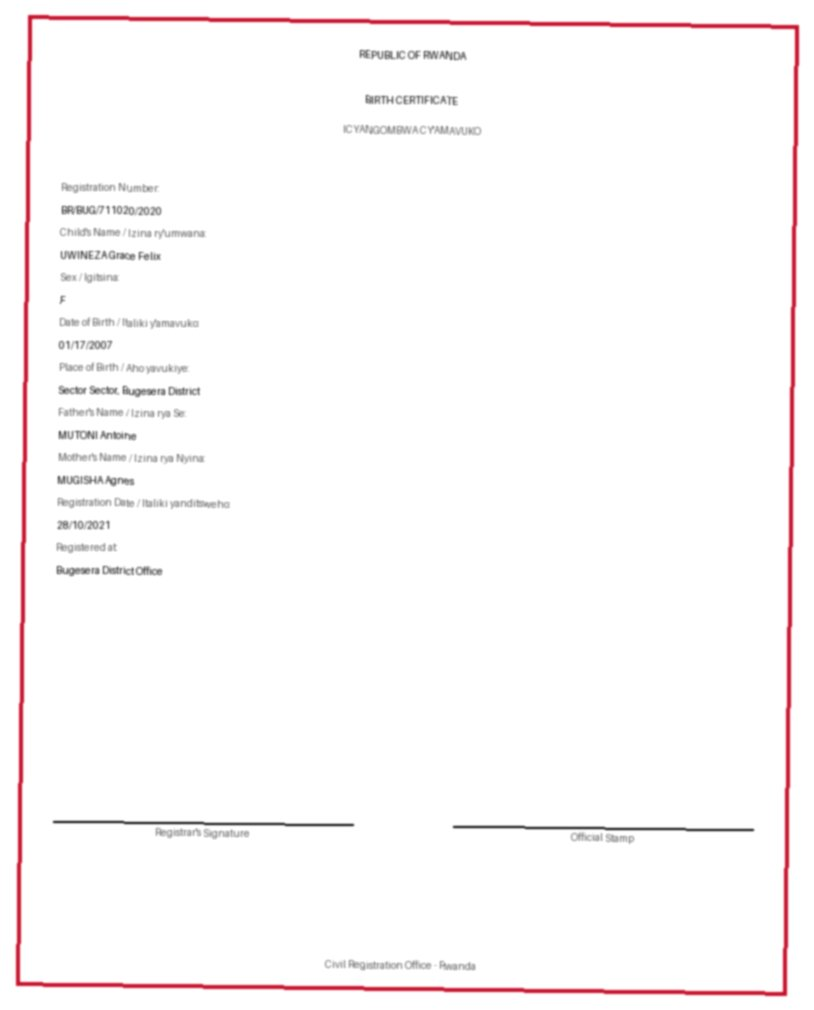

Using image: samples_documents\sample_birth_invalid.jpg


In [46]:
# List available images in the samples_documents folder for Grad-CAM input
import os
from IPython.display import display, Image

input_dir = 'samples_documents'  # Use this folder for Grad-CAM input images
image_files = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

print('Available images in samples_documents folder:')
for img in image_files:
    print(img)

# Display the first image as an example and set img_path
if image_files:
    img_path = os.path.join(input_dir, image_files[0])
    display(Image(filename=img_path))
    print(f'Using image: {img_path}')
else:
    raise FileNotFoundError('No images found in samples_documents folder.')

c:\xampp\htdocs\aipowered\.venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


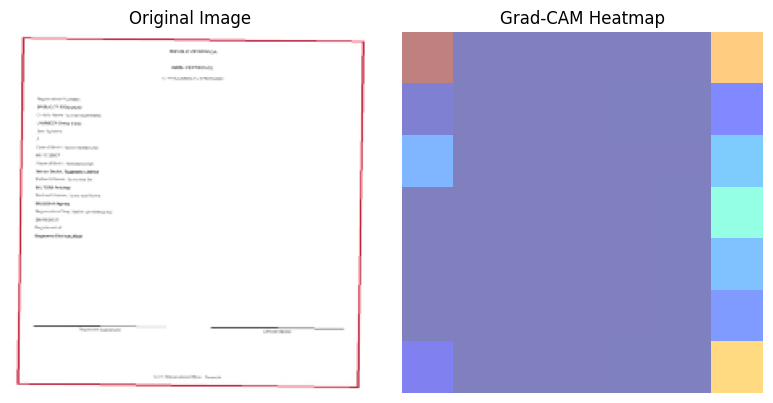

In [ ]:
print("Grad-CAM visualization is not yet implemented in this notebook. This feature is planned for a future version to provide explainable AI heatmaps for model predictions.")

### 2.1 Synthetic Document Generation
Generates synthetic Rwandan government documents using RwandanDocumentGenerator.

### 2.2 High-Risk Dataset Generation
Fetches citizen records from MySQL and generates valid/invalid document images per identity.

### 2.4 Rwandan Combined Dataset — Loading & Group-Wise Split
Loads fixed synthetic and high-risk images, assigns sample weights, and splits by identity group to prevent leakage.

## 7. Model Persistence
Saves the champion model weights and full model file to disk.

## 7. Model Persistence
Saves the champion model weights and full model file to disk for deployment.

## 8. Appendix — Experimental Modules
Supporting experiments: architecture comparison, classical ML, feature analysis, and additional diagnostics.

### 8.1 AI Forensic Layer — OCR & Structural Integrity
Simulates OCR-based forensic scoring and structural template matching to detect text tampering and layout anomalies. This layer complements the deep learning model by catching character substitutions and document structure deviations that pixel-level analysis may miss.